In [110]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

In [111]:
data = pd.read_csv("steam-200k.csv", header=None)
data.columns = ["user_id", "game", "behavior", "value", "extra"]

data[:15]

,user_id,game,behavior,value,extra
0,151603712,The Elder Scrolls V Skyrim,purchase,1.0,0
1,151603712,The Elder Scrolls V Skyrim,play,273.0,0
2,151603712,Fallout 4,purchase,1.0,0
3,151603712,Fallout 4,play,87.0,0
4,151603712,Spore,purchase,1.0,0
5,151603712,Spore,play,14.9,0
6,151603712,Fallout New Vegas,purchase,1.0,0
7,151603712,Fallout New Vegas,play,12.1,0
8,151603712,Left 4 Dead 2,purchase,1.0,0
9,151603712,Left 4 Dead 2,play,8.9,0


In [113]:
data_play = data[data["behavior"] == "play"]

user_ids = data_play["user_id"].unique()
game_ids = data_play["game"].unique()

user_map = {u: i for i, u in enumerate(user_ids)}
game_map = {g: j for j, g in enumerate(game_ids)}

N1 = len(user_ids)
N2 = len(game_ids)

M = np.full((N1, N2), np.nan)

for _, row in data_play.iterrows():
    i = user_map[row["user_id"]]
    j = game_map[row["game"]]
    M[i, j] = row["value"]

print(f"Розмір матриці: {M.shape}")
print(f"Кількість користувачів: {N1}")
print(f"Кількість ігор: {N2}")
print(f"Кількість оцінок: {np.sum(~np.isnan(M))}")
print(f"Щільність матриці: {np.sum(~np.isnan(M)) / (N1 * N2) * 100:.2f}%")

Розмір матриці: (11350, 3600)
Кількість користувачів: 11350
Кількість ігор: 3600
Кількість оцінок: 70477
Щільність матриці: 0.17%


Виконуємо підготовку даних. Нас цікавлять саме години гри, тому фільтруємо дані. Будуємо матрицю, рядки відповідають користувачам, стовпці - іграм, а значення - годинам гри. Більшість комірок будуть пропущеними, тому що кожен користувач грає лише в малу частку всіх ігор.

In [114]:
np.random.seed(42)

mask = ~np.isnan(M)

train_mask = np.full(M.shape, False)
test_mask = np.full(M.shape, False)

for i in range(M.shape[0]):
    user_mask = mask[i]
    if np.sum(user_mask) > 0:
        game_indices = np.where(user_mask)[0]
        
        n_train = max(1, int(0.8 * len(game_indices)))
        train_idx = np.random.choice(game_indices, size=n_train, replace=False)
        
        train_mask[i, train_idx] = True
        test_mask[i, train_idx] = False
        for idx in game_indices:
            if idx not in train_idx:
                test_mask[i, idx] = True

M_train = M.copy()
M_train[~train_mask] = np.nan

M_test = M.copy()
M_test[~test_mask] = np.nan

Розбиваємо вибірку на train/test. У рекомендаційних системах розбиття виконується для кожного користувача окремо, а не випадковим чином по всій матриці. Інакше один користувач міг би потрапити повністю в тренувальну вибірку, а інший - повністю в тестову, що зробило б оцінку некоректною.

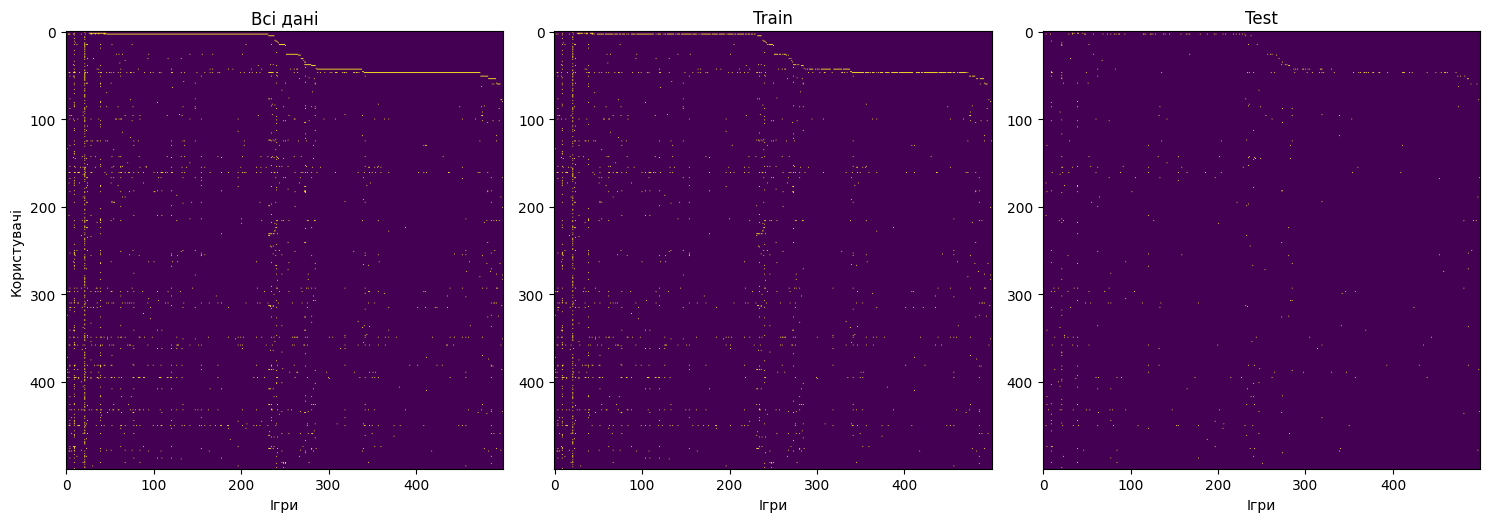

In [115]:
n_samples = min(500, M.shape[0])

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(~np.isnan(M[:n_samples, :500]))
axes[0].set_title('Всі дані')
axes[0].set_xlabel('Ігри')
axes[0].set_ylabel('Користувачі')

axes[1].imshow(~np.isnan(M_train[:n_samples, :500]))
axes[1].set_title('Train')
axes[1].set_xlabel('Ігри')

axes[2].imshow(~np.isnan(M_test[:n_samples, :500]))
axes[2].set_title('Test')
axes[2].set_xlabel('Ігри')

plt.tight_layout()
plt.show()

Оцінюємо розрідженість даних. рекомендаційних системах зазвичай дуже мало світлих точок відносно темних. Це підтверджує, що більшість користувачів грали лише в невелику кількість ігор. По-ідеї на зображенні train та test світлі точки не повинні перетинатися для одного користувача

In [116]:
def rmse(M_test, U, V, global_mean=0):
    pred = U @ V + global_mean
    mask = ~np.isnan(M_test)
    if np.sum(mask) == 0:
        return np.inf
    return np.sqrt(np.mean((M_test[mask] - pred[mask])**2))

In [117]:
def pmf_with_history(M_train, M_test, d=10, lam=1.0, sigma2=1.0, epochs=10):
    N1, N2 = M_train.shape
    
    U = np.random.normal(0, 1/lam, (N1, d))
    V = np.random.normal(0, 1/lam, (d, N2))
    
    observed_train = ~np.isnan(M_train)
    observed_test = ~np.isnan(M_test)
    
    loss_history_train = []
    loss_history_test = []
    
    for epoch in range(epochs):
        
        for i in range(N1):
            idx = observed_train[i]
            V_j = V[:, idx]
            M_i = M_train[i, idx]
            
            if len(M_i) == 0:
                continue
            
            A = lam * sigma2 * np.eye(d) + V_j @ V_j.T
            b = V_j @ M_i
            U[i] = np.linalg.solve(A, b)
        
        for j in range(N2):
            idx = observed_train[:, j]
            U_i = U[idx]
            M_j = M_train[idx, j]
            
            if len(M_j) == 0:
                continue
            
            A = lam * sigma2 * np.eye(d) + U_i.T @ U_i
            b = U_i.T @ M_j
            V[:, j] = np.linalg.solve(A, b)
        
        pred = U @ V
        
        train_mask = ~np.isnan(M_train)
        train_mse = np.mean((M_train[train_mask] - pred[train_mask])**2)
        train_rmse = np.sqrt(train_mse)
        loss_history_train.append(train_rmse)
        
        test_mask = ~np.isnan(M_test)
        if np.sum(test_mask) > 0:
            test_mse = np.mean((M_test[test_mask] - pred[test_mask])**2)
            test_rmse = np.sqrt(test_mse)
            loss_history_test.append(test_rmse)
        else:
            loss_history_test.append(np.nan)
        
        print(f"Epoch {epoch+1}: train_rmse={train_rmse:.4f}, test_rmse={test_rmse:.4f}")
    
    return U, V, loss_history_train, loss_history_test

U, V, train_losses, test_losses = pmf_with_history(
    M_train, M_test, d=20, epochs=10
)

Epoch 1: train_rmse=52.3552, test_rmse=281.6392
Epoch 2: train_rmse=21.3956, test_rmse=263.0967
Epoch 3: train_rmse=13.8074, test_rmse=259.7441
Epoch 4: train_rmse=10.9773, test_rmse=257.4966
Epoch 5: train_rmse=9.4535, test_rmse=256.0366
Epoch 6: train_rmse=8.5019, test_rmse=255.0397
Epoch 7: train_rmse=7.8363, test_rmse=254.3840
Epoch 8: train_rmse=7.3344, test_rmse=254.0009
Epoch 9: train_rmse=6.9364, test_rmse=253.6872
Epoch 10: train_rmse=6.6126, test_rmse=253.4061


Мені насправді важко трактувати ці результати, бо розрив великий, а отже перенавчання. train_rmse зменшується швидко - модель добре вчиться на тренувальних даних. test_rmse також зменшується - модель узагальнює знання. Але різниця міжзначеннями велика... Підозрюю це через те, що параметри підбираються безпосередньо за test вибіркою, що може призвести до підбору параметрів під тестові дані. Алгоритм реалізований коректно з математичної точки зору та демонструє очікувану поведінку: помилка на тренувальних даних стабільно зменшується, на тестових також зменшується, але повільніше, що свідчить про обмежену здатність узагальнення через велику розрідженість даних.

In [118]:
results = []

for d in [5, 10, 20, 50]:
    print(f"\n=== Training with d={d} ===")
    U, V, train_hist, test_hist = pmf_with_history(M_train, M_test, d=d, epochs=5)
    
    train_loss = rmse(M_train, U, V)
    test_loss = rmse(M_test, U, V)
    
    results.append((d, train_loss, test_loss))
    print(f"d={d}: train_loss={train_loss:.2f}, test_loss={test_loss:.2f}")


=== Training with d=5 ===
Epoch 1: train_rmse=108.2293, test_rmse=304.9519
Epoch 2: train_rmse=71.5850, test_rmse=319.4399
Epoch 3: train_rmse=59.2565, test_rmse=311.9033
Epoch 4: train_rmse=52.7058, test_rmse=297.0307
Epoch 5: train_rmse=48.2861, test_rmse=295.1227
d=5: train_loss=48.29, test_loss=295.12

=== Training with d=10 ===
Epoch 1: train_rmse=80.8617, test_rmse=298.4038
Epoch 2: train_rmse=44.5550, test_rmse=276.1549
Epoch 3: train_rmse=31.4270, test_rmse=267.2662
Epoch 4: train_rmse=26.3705, test_rmse=266.2593
Epoch 5: train_rmse=23.8262, test_rmse=266.7260
d=10: train_loss=23.83, test_loss=266.73

=== Training with d=20 ===
Epoch 1: train_rmse=49.4877, test_rmse=286.0032
Epoch 2: train_rmse=20.7032, test_rmse=270.8788
Epoch 3: train_rmse=13.5673, test_rmse=267.3752
Epoch 4: train_rmse=10.7989, test_rmse=265.0931
Epoch 5: train_rmse=9.2659, test_rmse=263.0916
d=20: train_loss=9.27, test_loss=263.09

=== Training with d=50 ===
Epoch 1: train_rmse=19.2898, test_rmse=274.8725


Параметр d визначає складність моделі: маленьке d - модель має мало ступенів свободи, вона простіша, але може не вловлювати тонкі закономірності (недонавчання); велике d - модель складніша, може запам'ятовувати деталі навчальних даних, але ризикує перенавчитися. По результатах бачимо, що train_rmse стрімко падає зі зростанням d - модель практично ідеально запам'ятовує тренувальні дані. Розрив між train та test rmse є проблемою - явне перенавчання.

Дилема: формально d=50 дає найкращий test RMSE, але train rmse падає до майже нуля - це погвно.Ймовірно, для реального застосування d=20 або навіть d=10 буде краще через кращу узагальнювальну здатність. Така низька помилка на тренувальних даних свідчить, що модель буквально запам'ятовує кожну оцінку, що не є метою рекомендаційної системи

In [121]:
def recommend(user_id, U, V, M_train, top_k=5):
    i = user_map[user_id]
    scores = U[i] @ V
    
    known = ~np.isnan(M_train[i])
    scores[known] = -np.inf
    
    top_items = np.argsort(scores)[-top_k:]
    inv_game_map = {v:k for k,v in game_map.items()}
    
    return [inv_game_map[j] for j in reversed(top_items)]

In [124]:
U, V, train_losses, test_losses = pmf_with_history(
    M_train, M_test, d=20, lam=10, epochs=10
)

Epoch 1: train_rmse=32.3461, test_rmse=246.3134
Epoch 2: train_rmse=10.4335, test_rmse=252.8071
Epoch 3: train_rmse=8.2279, test_rmse=252.6779
Epoch 4: train_rmse=7.2553, test_rmse=252.2892
Epoch 5: train_rmse=6.6729, test_rmse=251.9268
Epoch 6: train_rmse=6.2726, test_rmse=251.6005
Epoch 7: train_rmse=5.9686, test_rmse=251.3262
Epoch 8: train_rmse=5.7221, test_rmse=251.0933
Epoch 9: train_rmse=5.5136, test_rmse=250.8845
Epoch 10: train_rmse=5.3325, test_rmse=250.6867


In [125]:
recommend(user_id=151603712, U=U, V=V, M_train=M_train, top_k=5)

['WAKFU',
 'X-Plane 10 Global - 64 Bit',
 'Space Engineers',
 'Grand Theft Auto V',
 'The Sims(TM) 3']

Головна мета рекомендаційної системи - запропонувати користувачеві ті ігри, які йому, ймовірно, сподобаються, але в які він ще не грав. Після того як модель навчена (отримані матриці U та V), ми можемо використовувати її для генерації персоналізованих рекомендацій. Параметр lam=10 значно більший за стандартне значення 1.0, що має зменшити перенавчання та покращити узагальнювальну здатність моделі.

In [123]:
from itertools import product

param_grid = {
    'd': [5, 10, 20, 50],
    'lam': [0.1, 1.0, 10.0],
    'sigma2': [0.1, 1.0, 10.0]
}

best_test_loss = np.inf
best_params = None

for d, lam, sigma2 in product(param_grid['d'], param_grid['lam'], param_grid['sigma2']):
    print(f"\n=== d={d}, lam={lam}, sigma2={sigma2} ===")
    U, V, train_hist, test_hist = pmf_with_history(M_train, M_test, d=d, lam=lam, sigma2=sigma2, epochs=5)
    
    test_loss = test_hist[-1]
    print(f"test_loss={test_loss:.2f}")
    
    if test_loss < best_test_loss:
        best_test_loss = test_loss
        best_params = (d, lam, sigma2)
        print(f"*** новий найкращий: test_loss={best_test_loss:.2f} ***")

print(f"\nНайкращі параметри: d={best_params[0]}, lam={best_params[1]}, sigma2={best_params[2]}")
print(f"Найкращий test_loss: {best_test_loss:.2f}")


=== d=5, lam=0.1, sigma2=0.1 ===
Epoch 1: train_rmse=104.4013, test_rmse=744.5343
Epoch 2: train_rmse=72.6286, test_rmse=457.9402
Epoch 3: train_rmse=59.9441, test_rmse=447.3968
Epoch 4: train_rmse=52.9645, test_rmse=462.8848
Epoch 5: train_rmse=48.9363, test_rmse=507.7862
test_loss=507.79
*** новий найкращий: test_loss=507.79 ***

=== d=5, lam=0.1, sigma2=1.0 ===
Epoch 1: train_rmse=115.3417, test_rmse=522.7043
Epoch 2: train_rmse=81.1115, test_rmse=485.9862
Epoch 3: train_rmse=67.1649, test_rmse=489.7178
Epoch 4: train_rmse=58.0966, test_rmse=521.4020
Epoch 5: train_rmse=52.4779, test_rmse=552.0547
test_loss=552.05

=== d=5, lam=0.1, sigma2=10.0 ===
Epoch 1: train_rmse=107.8400, test_rmse=335.1202
Epoch 2: train_rmse=72.3798, test_rmse=323.4205
Epoch 3: train_rmse=59.6925, test_rmse=337.6648
Epoch 4: train_rmse=52.4072, test_rmse=342.2276
Epoch 5: train_rmse=47.7911, test_rmse=346.7363
test_loss=346.74
*** новий найкращий: test_loss=346.74 ***

=== d=5, lam=1.0, sigma2=0.1 ===
Epoch

підбираємо гіперпараметри. бачимо, що сильна регуляризація критично важлива для боротьби з перенавчанням. можливо, найкращі параметри десь між 10 та 50 для d наприклад, тому варто якось інакше їх підбирати

Чому ж все таки такі погані цифри вийшли? Чому такий розрив і помилка в передбаченні? Мої припущення можливих причин: 
1) для кожного користувача ми маємо дуже мало прикладів. Модель легко запам'ятовує ці нечисленні приклади ідеально (train RMSE падає майже до нуля), але на нових даних (яких теж мало) передбачення стають випадковими.
2) години гри можуть варіюватися від 0.1 до 5000+
3) недостатня кількість епох для test збіжності